In [33]:
import matplotlib.pyplot as plt
import pandas as pd

In [34]:
# loading experiment results from csv files
cf_au_ai = pd.read_csv("experiment_results/cf_all_users_all_items_experiment_results.csv")
cf_au_aisles = pd.read_csv("experiment_results/cf_all_users_aisles_experiment_results.csv")
cf_uc_ai = pd.read_csv("experiment_results/cf_user_clusters_all_items_experiment_results.csv") 
cf_uc_aisles = pd.read_csv("experiment_results/cf_user_clusters_aisles_experiment_results.csv") 
mba = pd.read_csv("experiment_results/mba_experiment_results.csv")

For the CF recommender with all users and all items:

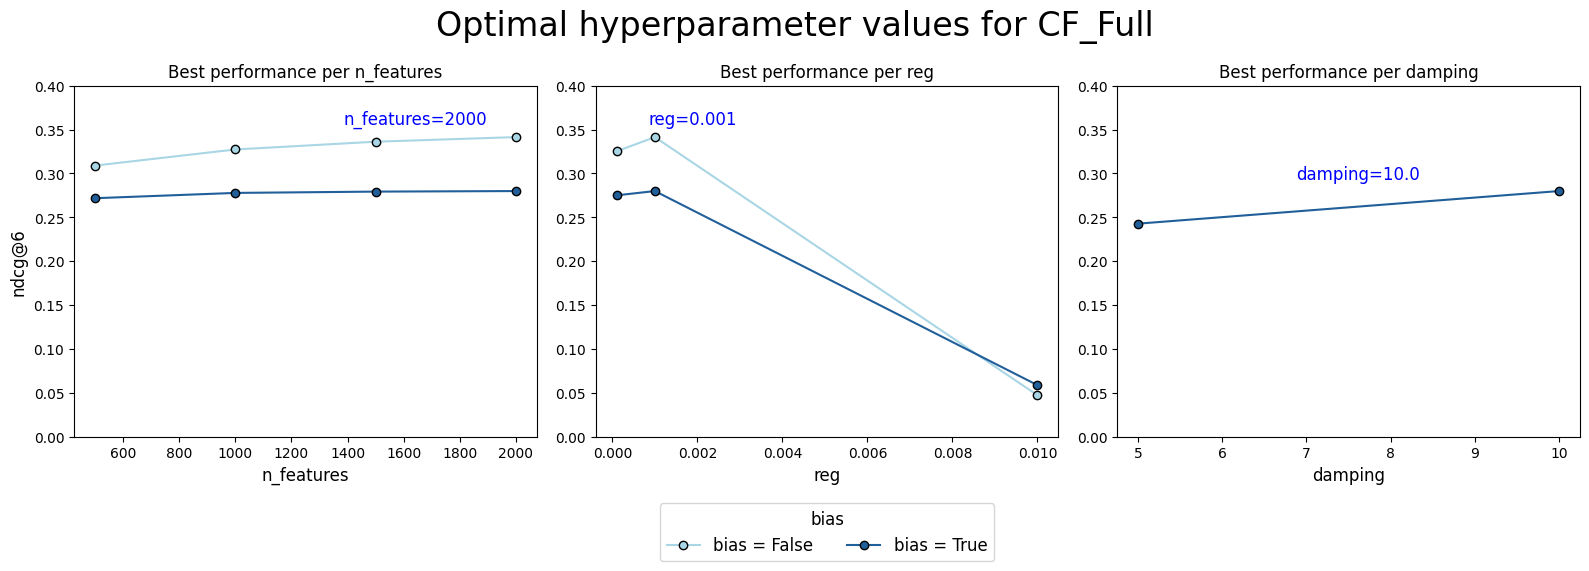

In [35]:
# initializing subplot
nrows, ncols = 1, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5))

# hyperparams to group by
hyperparams = ["n_features", "reg", "damping"]

# color dict
color_dict = {True: "#215F9A",
              False: "#a9d6e5"}

for i, hyperparam in enumerate(hyperparams):
    grp_df = cf_au_ai.groupby([hyperparam, "bias_value"])["avg_ndcg"].max().reset_index(name="ndcg")
    for bias, group in grp_df.groupby("bias_value"):
        color = color_dict[bias]
        axes[i].plot(group[hyperparam], group["ndcg"], marker="o", label=f"bias = {bias}", c=color, markeredgecolor="black")

    axes[i].set_xlabel(f"{hyperparam}", fontsize=12)
    axes[i].set_title(f"Best performance per {hyperparam}")
    axes[i].set_ylim((0,0.4))

    # annotating the best performance achieved (place annotation at the actual data point)
    best_idx = grp_df["ndcg"].idxmax()
    best_x = grp_df.loc[best_idx, hyperparam]
    best_y = grp_df.loc[best_idx, "ndcg"]
    axes[i].annotate(f"{hyperparam}={best_x}",
                     xy=(best_x*0.68, best_y*1.02),
                     xytext=(5, 5),
                     textcoords="offset points",
                     ha="left", fontsize=12, color="blue",
                     clip_on=False)

    if i == 0:
        axes[i].set_ylabel("ndcg@6", fontsize=12)

# overall title
fig.suptitle("Optimal hyperparameter values for CF_Full", fontsize=24)

# adding legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, 
           title="bias", 
           loc="lower center", 
           ncol=4, 
           fontsize=12, 
           title_fontsize=12,
           bbox_to_anchor=(0.52, -0.14))

fig.tight_layout()

For the CF recommender with all users and aisles:

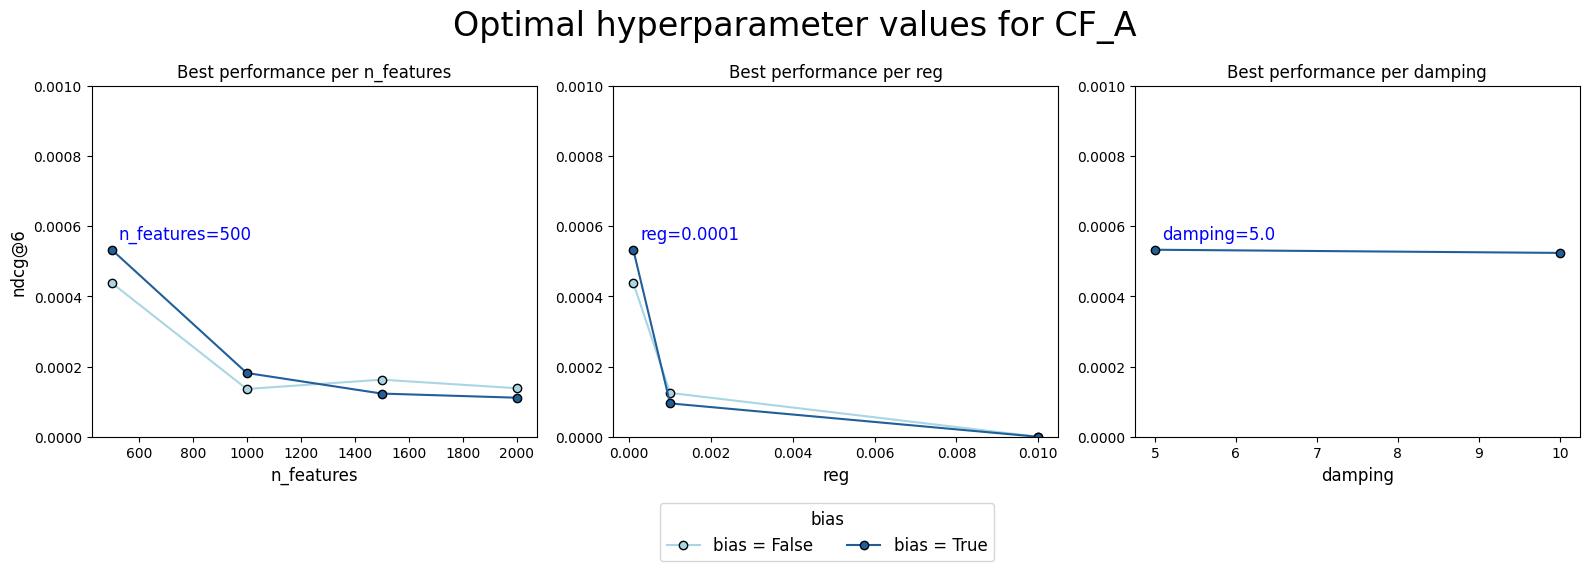

In [36]:
# initializing subplot
nrows, ncols = 1, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5))

# hyperparams to group by
hyperparams = ["n_features", "reg", "damping"]

# color dict
color_dict = {True: "#215F9A",
              False: "#a9d6e5"}

for i, hyperparam in enumerate(hyperparams):
    grp_df = cf_au_aisles.groupby([hyperparam, "bias_value"])["avg_ndcg"].max().reset_index(name="ndcg")
    for bias, group in grp_df.groupby("bias_value"):
        color = color_dict[bias]
        axes[i].plot(group[hyperparam], group["ndcg"], marker="o", label=f"bias = {bias}", c=color, markeredgecolor="black")

    axes[i].set_xlabel(f"{hyperparam}", fontsize=12)
    axes[i].set_title(f"Best performance per {hyperparam}")
    axes[i].set_ylim((0,0.001))

    # annotating the best performance achieved (place annotation at the actual data point)
    best_idx = grp_df["ndcg"].idxmax()
    best_x = grp_df.loc[best_idx, hyperparam]
    best_y = grp_df.loc[best_idx, "ndcg"]
    axes[i].annotate(f"{hyperparam}={best_x}",
                     xy=(best_x, best_y*1.02),
                     xytext=(5, 5),
                     textcoords="offset points",
                     ha="left", fontsize=12, color="blue",
                     clip_on=False)

    if i == 0:
        axes[i].set_ylabel("ndcg@6", fontsize=12)

# overall title
fig.suptitle("Optimal hyperparameter values for CF_A", fontsize=24)

# adding legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, 
           title="bias", 
           loc="lower center", 
           ncol=4, 
           fontsize=12, 
           title_fontsize=12,
           bbox_to_anchor=(0.52, -0.14))

fig.tight_layout()

For the CF recommender with user clusters and all items:

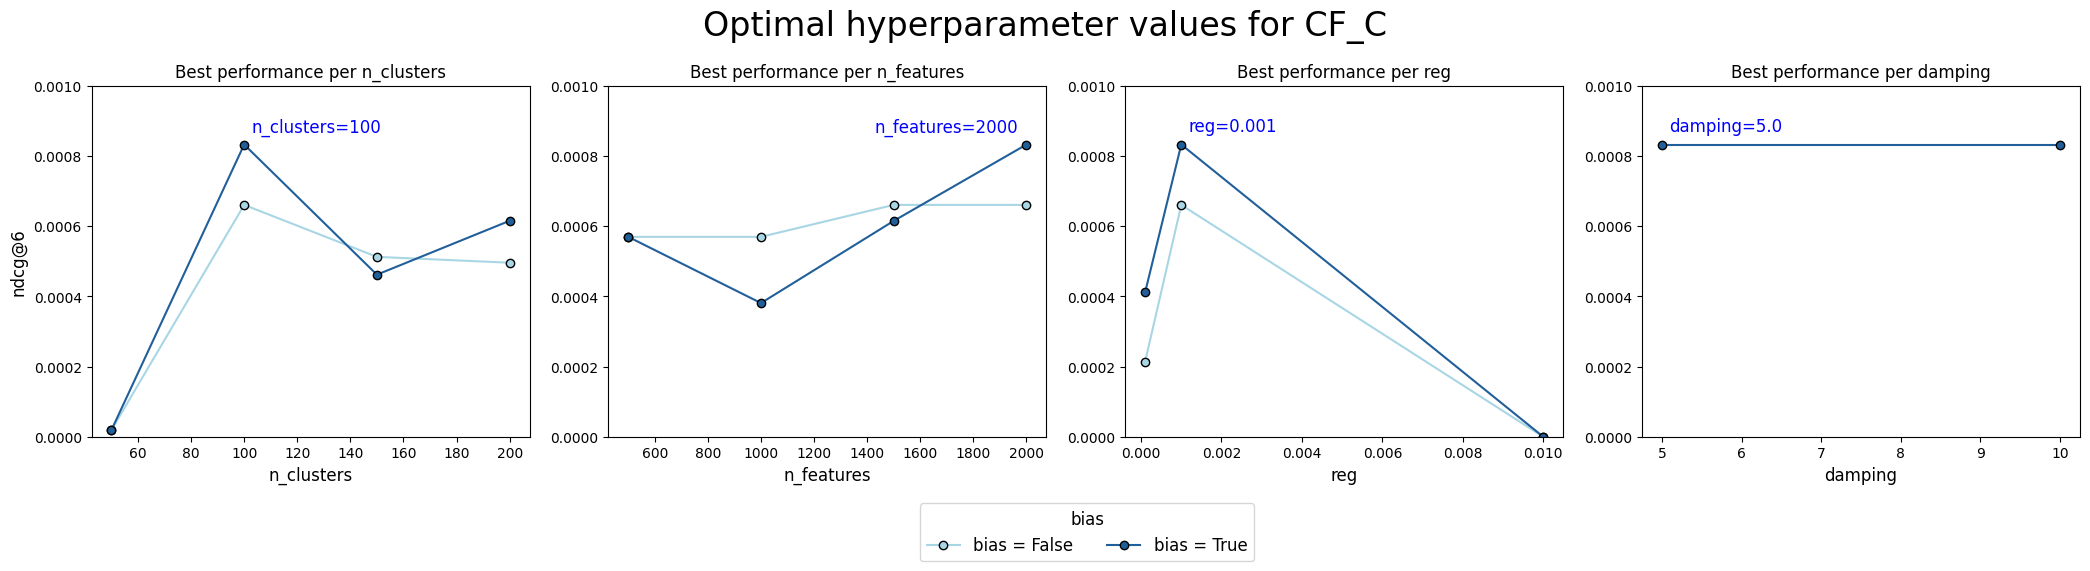

In [37]:
# initializing subplot
nrows, ncols = 1, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(21, 5))

# hyperparams to group by
hyperparams = ["n_clusters", "n_features", "reg", "damping"]

# color dict
color_dict = {True: "#215F9A",
              False: "#a9d6e5"}

for i, hyperparam in enumerate(hyperparams):
    grp_df = cf_uc_ai.groupby([hyperparam, "bias_value"])["avg_ndcg"].max().reset_index(name="ndcg")
    for bias, group in grp_df.groupby("bias_value"):
        color = color_dict[bias]
        axes[i].plot(group[hyperparam], group["ndcg"], marker="o", label=f"bias = {bias}", c=color, markeredgecolor="black")

    axes[i].set_xlabel(f"{hyperparam}", fontsize=12)
    axes[i].set_title(f"Best performance per {hyperparam}")
    axes[i].set_ylim((0,0.001))

    # annotating the best performance achieved (place annotation at the actual data point)
    best_idx = grp_df["ndcg"].idxmax()
    best_x = grp_df.loc[best_idx, hyperparam]
    best_y = grp_df.loc[best_idx, "ndcg"]
    if hyperparam == "n_features":
            axes[i].annotate(f"{hyperparam}={best_x}",
                        xy=(best_x*0.7, best_y*1.02),
                        xytext=(5, 5),
                        textcoords="offset points",
                        ha="left", fontsize=12, color="blue",
                        clip_on=False)
    else:
        axes[i].annotate(f"{hyperparam}={best_x}",
                        xy=(best_x, best_y*1.02),
                        xytext=(5, 5),
                        textcoords="offset points",
                        ha="left", fontsize=12, color="blue",
                        clip_on=False)

    if i == 0:
        axes[i].set_ylabel("ndcg@6", fontsize=12)

# overall title
fig.suptitle("Optimal hyperparameter values for CF_C", fontsize=24)

# adding legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, 
           title="bias", 
           loc="lower center", 
           ncol=4, 
           fontsize=12, 
           title_fontsize=12,
           bbox_to_anchor=(0.52, -0.14))

fig.tight_layout()

For the CF recommender with user clusters and aisles:

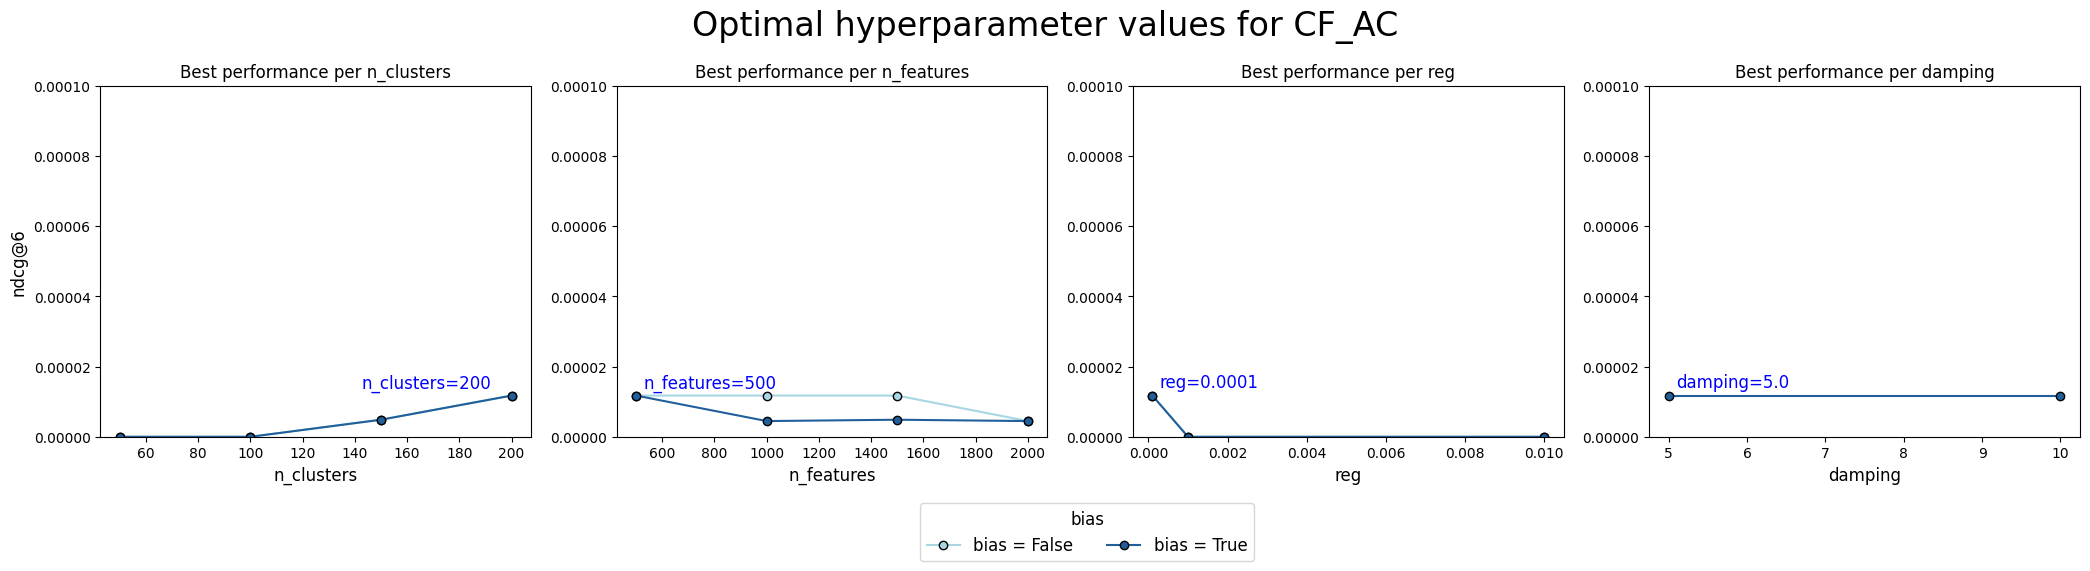

In [38]:
# initializing subplot
nrows, ncols = 1, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(21, 5))

# hyperparams to group by
hyperparams = ["n_clusters", "n_features", "reg", "damping"]

# color dict
color_dict = {True: "#215F9A",
              False: "#a9d6e5"}

for i, hyperparam in enumerate(hyperparams):
    grp_df = cf_uc_aisles.groupby([hyperparam, "bias_value"])["avg_ndcg"].max().reset_index(name="ndcg")
    for bias, group in grp_df.groupby("bias_value"):
        color = color_dict[bias]
        axes[i].plot(group[hyperparam], group["ndcg"], marker="o", label=f"bias = {bias}", c=color, markeredgecolor="black")

    axes[i].set_xlabel(f"{hyperparam}", fontsize=12)
    axes[i].set_title(f"Best performance per {hyperparam}")
    axes[i].set_ylim((0,0.0001))

    # annotating the best performance achieved (place annotation at the actual data point)
    best_idx = grp_df["ndcg"].idxmax()
    best_x = grp_df.loc[best_idx, hyperparam]
    best_y = grp_df.loc[best_idx, "ndcg"]
    if hyperparam == "n_clusters":
        axes[i].annotate(f"{hyperparam}={best_x}",
                        xy=(best_x*0.7, best_y*1.02),
                        xytext=(5, 5),
                        textcoords="offset points",
                        ha="left", fontsize=12, color="blue",
                        clip_on=False)
    else:
        axes[i].annotate(f"{hyperparam}={best_x}",
                        xy=(best_x, best_y*1.02),
                        xytext=(5, 5),
                        textcoords="offset points",
                        ha="left", fontsize=12, color="blue",
                        clip_on=False)

    if i == 0:
        axes[i].set_ylabel("ndcg@6", fontsize=12)

# overall title
fig.suptitle("Optimal hyperparameter values for CF_AC", fontsize=24)

# adding legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, 
           title="bias", 
           loc="lower center", 
           ncol=4, 
           fontsize=12, 
           title_fontsize=12,
           bbox_to_anchor=(0.52, -0.14))

fig.tight_layout()

For the MBA recommender:

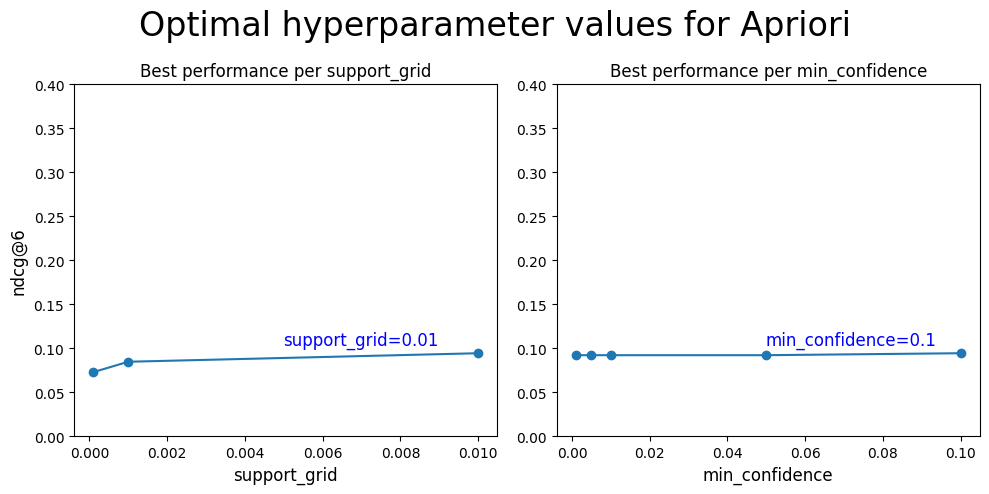

In [39]:
# initializing subplot
nrows, ncols = 1, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5))

# hyperparams to group by
hyperparams = ["support_grid", "min_confidence"]

for i, hyperparam in enumerate(hyperparams):
    grp_df = mba.groupby([hyperparam])["avg_ndcg"].max().reset_index(name="ndcg")
    axes[i].plot(grp_df[hyperparam], grp_df["ndcg"], marker="o")

    axes[i].set_xlabel(f"{hyperparam}", fontsize=12)
    axes[i].set_title(f"Best performance per {hyperparam}")
    axes[i].set_ylim((0,0.4))

    # annotating the best performance achieved (place annotation at the actual data point)
    best_idx = grp_df["ndcg"].idxmax()
    best_x = grp_df.loc[best_idx, hyperparam]
    best_y = grp_df.loc[best_idx, "ndcg"]
    axes[i].annotate(f"{hyperparam}={best_x}",
                     xy=(best_x*0.48, best_y*1.02),
                     xytext=(5, 5),
                     textcoords="offset points",
                     ha="left", fontsize=12, color="blue",
                     clip_on=False)

    if i == 0:
        axes[i].set_ylabel("ndcg@6", fontsize=12)

# overall title
fig.suptitle("Optimal hyperparameter values for Apriori", fontsize=24)

fig.tight_layout()